# 📊 YouTube Channel Exploratory Data Analysis
This notebook analyzes YouTube channel data from **three different perspectives** to understand the impact of categories, activity, and channel attributes on performance (views, subscribers, and growth).

## 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')


## 📥 Load Dataset


In [2]:
df = pd.read_csv('cleaned_youtube_data_new_1.csv')
df.head()

,channel_name,view_count,category,country,subscriber_count,created_date,video_count,videos_last_30_days,views_last_30_days,view_count_log1p,subscriber_count_log1p,video_count_log1p,videos_last_30_days_log1p,views_last_30_days_log1p,channel_created_year,channel_age_years
0,BLACKPINK,39962585446,Music of Asia,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
1,BLACKPINK,39962585446,Pop music,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
2,BLACKPINK,39962585446,Music,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
3,BLACKPINK,39962585446,Electronic music,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
4,HYBE LABELS,41604896923,Hip hop music,KR,78700000,2008-06-04 08:23:22+00:00,2817,79,46074833,24.451484,18.181154,7.943783,4.382027,17.645777,2008,17.43


# 🔹 Option A — Unique Channels Only (Drop Duplicates)
This approach removes duplicate rows caused by channels appearing under multiple categories. It allows us to observe **general global relationships** without category-based repetition.

### 📌 Create Unique Dataset

In [3]:
df_unique = df.drop_duplicates(subset=['channel_name'])
df_unique.shape

(15829, 16)

### 🔥 Heatmap — What It Shows
This heatmap visualizes correlations between numeric fields. It helps answer:
- Do more subscribers generally mean more views?
- Does uploading more videos increase recent 30-day performance?
- How do long-term metrics relate to short-term activity?

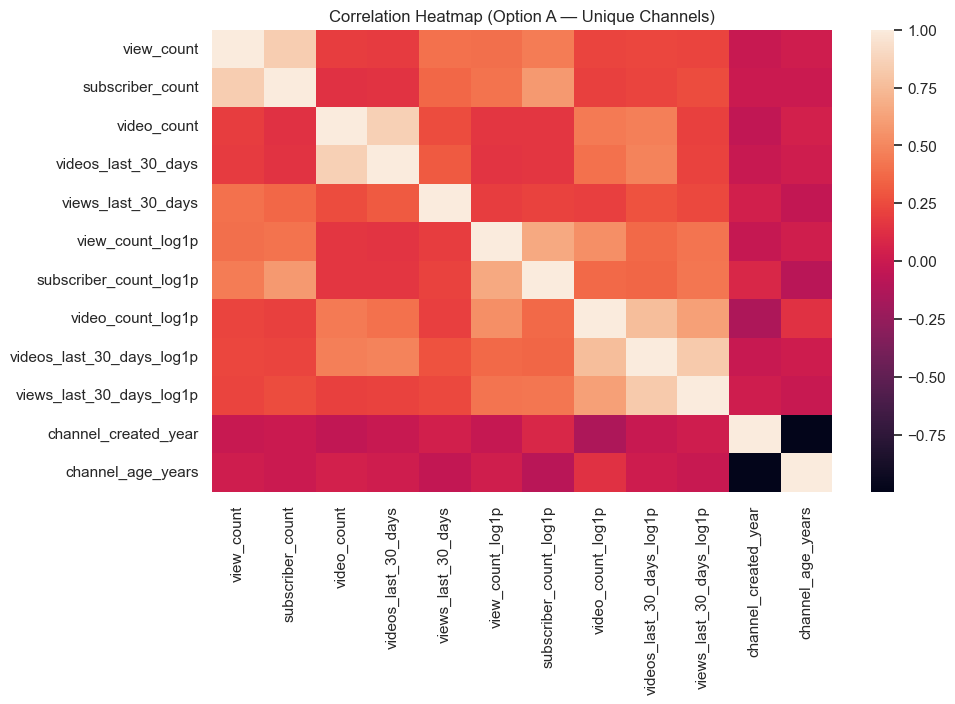

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(df_unique.select_dtypes(include=np.number).corr(), annot=False)
plt.title("Correlation Heatmap (Option A — Unique Channels)")
plt.show()

### 📈 Scatter Plot — Subscribers vs Total Views
This graph shows whether channels with more subscribers also accumulate more lifetime views. We expect a **positive trend**, but outliers may reveal channels with unusually high view counts compared to their subscriber base.

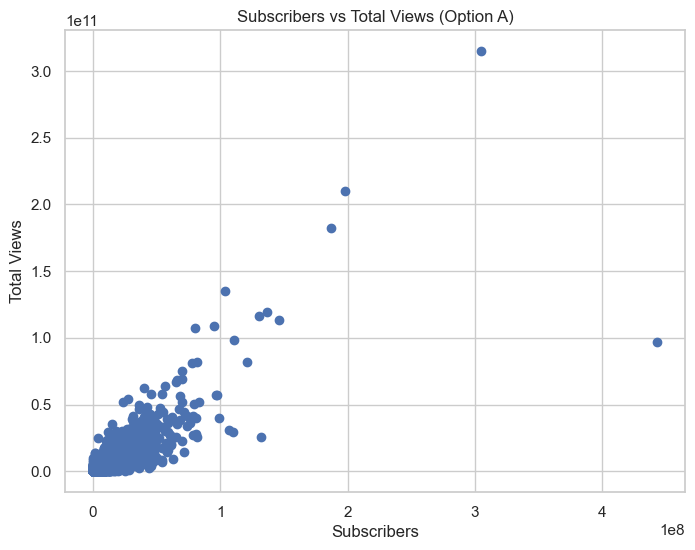

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(df_unique['subscriber_count'], df_unique['view_count'])
plt.xlabel("Subscribers")
plt.ylabel("Total Views")
plt.title("Subscribers vs Total Views (Option A)")
plt.show()

# 🔹 Option B — Aggregated by Channel
This method groups entries by channel. When a channel appears under multiple categories, we use:
- **Most common category**
- **Maximum values** for stable attributes (views, subscribers)
- **Mean values** for dynamic activity metrics (30-day stats)

This gives the **cleanest, most statistically correct dataset**.

### 📌 Create Aggregated Dataset

In [6]:

df_agg = df.groupby('channel_name').agg({
    'category': lambda x: x.mode()[0],
    'view_count': 'max',
    'subscriber_count': 'max',
    'video_count': 'max',
    'views_last_30_days': 'mean',
    'videos_last_30_days': 'mean',
    'channel_age_years': 'max',
    'country': lambda x: x.mode()[0]
}).reset_index()

df_agg.head()

,channel_name,category,view_count,subscriber_count,video_count,views_last_30_days,videos_last_30_days,channel_age_years,country
0,Cement Craft Ideas - DIY Creations,Hobby,49435372,634000,78,155815.0,7.0,7.62,US
1,bleedem,Electronic music,556817004,2290000,14,0.0,0.0,7.65,Unknown
2,#Mentale Zuflucht,Entertainment,910092875,1310000,1649,475005.0,12.0,9.08,Unknown
3,#Mind Warehouse,Lifestyle (sociology),2268827209,8490000,960,3981532.0,21.0,12.25,US
4,#Sport Channel,Boxing,78339613,136000,48,0.0,0.0,10.70,US


### 🔥 Heatmap — Aggregated Dataset
This visualization reveals **true correlations** without repeated rows. It shows whether long-term factors (age, total videos, lifetime views) influence short-term performance metrics (recent views, uploads).

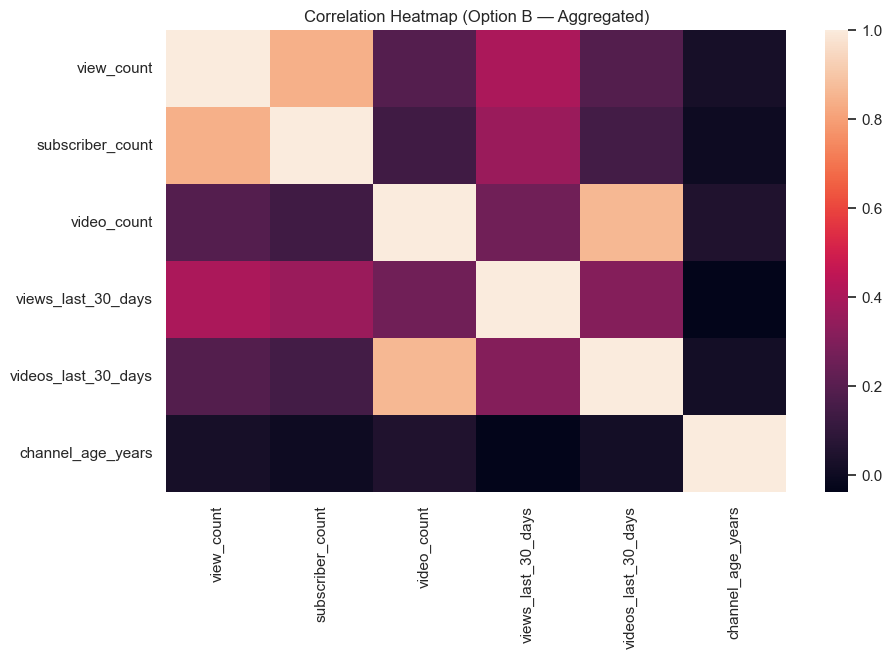

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df_agg.select_dtypes(include=np.number).corr(), annot=False)
plt.title("Correlation Heatmap (Option B — Aggregated)")
plt.show()

### 📈 Video Count vs Total Views
We observe whether channels that upload more videos achieve higher total views. A strong positive pattern may indicate the importance of **consistent long-term content production**.

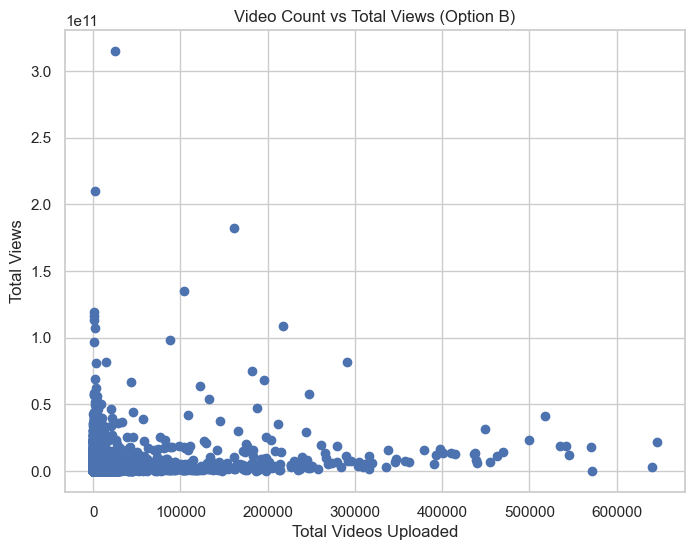

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(df_agg['video_count'], df_agg['view_count'])
plt.xlabel("Total Videos Uploaded")
plt.ylabel("Total Views")
plt.title("Video Count vs Total Views (Option B)")
plt.show()

# 🔹 Option C — Category-Expanded Dataset (Keep All Rows)
This version preserves all category-specific entries. It is useful for understanding **how categories influence performance**, at the risk of duplicates affecting numeric relationships.

In [9]:
df_c = df.copy(); df_c.head()

,channel_name,view_count,category,country,subscriber_count,created_date,video_count,videos_last_30_days,views_last_30_days,view_count_log1p,subscriber_count_log1p,video_count_log1p,videos_last_30_days_log1p,views_last_30_days_log1p,channel_created_year,channel_age_years
0,BLACKPINK,39962585446,Music of Asia,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
1,BLACKPINK,39962585446,Pop music,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
2,BLACKPINK,39962585446,Music,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
3,BLACKPINK,39962585446,Electronic music,KR,99000000,2016-06-29 03:15:23+00:00,636,1,3256869,24.411209,18.410630,6.456770,0.693147,14.996277,2016,9.37
4,HYBE LABELS,41604896923,Hip hop music,KR,78700000,2008-06-04 08:23:22+00:00,2817,79,46074833,24.451484,18.181154,7.943783,4.382027,17.645777,2008,17.43


### 📦 Boxplot — View Distribution by Category
This visualization compares how different content categories perform.
It answers:
- Which categories attract the highest view counts?
- Are some categories more volatile (wide spread)?
- Do trends differ between entertainment, music, gaming, etc.?

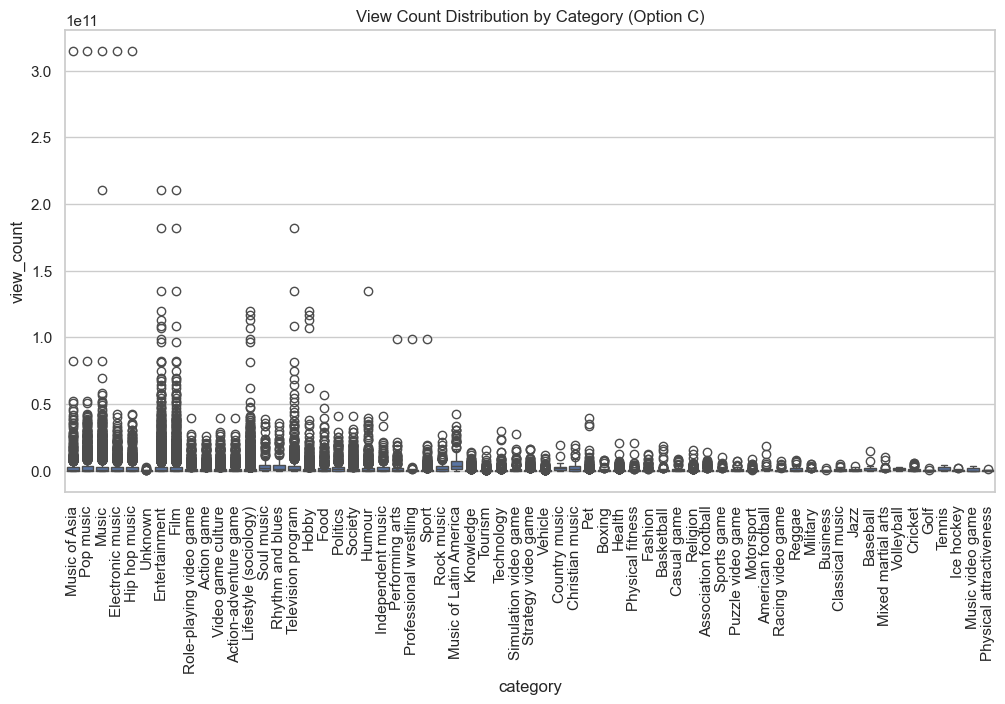

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_c, x='category', y='view_count')
plt.xticks(rotation=90)
plt.title("View Count Distribution by Category (Option C)")
plt.show()

### 📊 Mean Subscribers per Category
This bar chart shows the average subscriber count within each category. It identifies:
- High-performing categories
- Categories with consistently strong channels
- Whether music, entertainment, or gaming attracts the biggest audiences

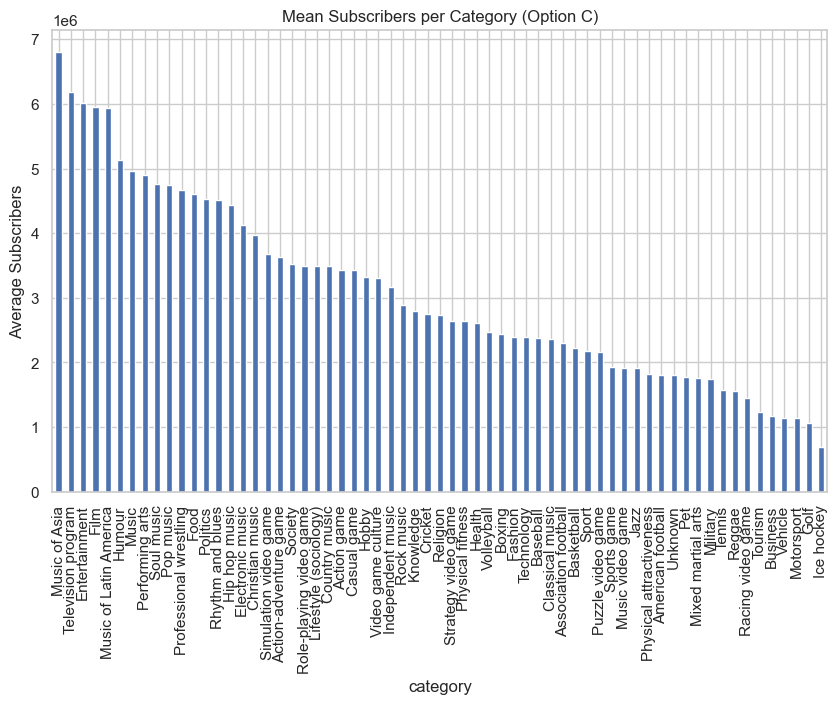

In [11]:
cat_subs = df_c.groupby('category')['subscriber_count'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
cat_subs.plot(kind='bar')
plt.ylabel("Average Subscribers")
plt.title("Mean Subscribers per Category (Option C)")
plt.show()